1. Importe o CSV e mostre shape, columns, dtypes.


In [ ]:
import pandas as pd
df_pix = pd.read_csv('pix_uso_mensal.csv')

In [3]:
print('shape')
print(df_pix.shape)

print('\ncolumns')
print(df_pix.columns)

print('\ndtypes')
print(df_pix.dtypes)

shape
(3000, 7)

columns
Index(['cliente_id', 'mes', 'segmento', 'idade', 'qtd_transacoes_pix',
       'valor_total_pix', 'canal_preferencial'],
      dtype='str')

dtypes
cliente_id                str
mes                       str
segmento                  str
idade                   int64
qtd_transacoes_pix      int64
valor_total_pix       float64
canal_preferencial        str
dtype: object


2. Use .describe() nas colunas numéricas.

In [7]:
df_pix[['idade','qtd_transacoes_pix','valor_total_pix']].describe()

,idade,qtd_transacoes_pix,valor_total_pix
count,3000.000000,3000.000000,3000.00000
mean,46.458000,15.124000,3666.63115
std,16.523899,11.411458,4274.25648
min,18.000000,0.000000,0.00000
25%,33.000000,8.000000,891.52250
50%,46.000000,11.000000,1465.68500
75%,61.000000,19.000000,5943.19500
max,74.000000,71.000000,25549.07000


3. Verifique nulos e duplicidades.


In [10]:
df_pix.isna().sum() #Verificando a quantidade de nulos em cada coluna

cliente_id            0
mes                   0
segmento              0
idade                 0
qtd_transacoes_pix    0
valor_total_pix       0
canal_preferencial    0
dtype: int64

In [12]:
df_pix.duplicated().sum() #Verificando a quantidade de duplicatas em cada coluna

np.int64(0)

4. Converta mes para um tipo apropriado para ordenação temporal (dica: pd.to_datetime com format='%Y-%m').


In [ ]:
df_pix['mes'] = pd.to_datetime(df_pix['mes'], format='%Y-%m')

In [17]:
df_pix.dtypes

cliente_id                       str
mes                   datetime64[us]
segmento                         str
idade                          int64
qtd_transacoes_pix             int64
valor_total_pix              float64
canal_preferencial               str
dtype: object

5. Use groupby('segmento') para calcular a média de qtd_transacoes_pix.


In [21]:
df_pix.groupby('segmento')['qtd_transacoes_pix'].mean().sort_values(ascending=False)

segmento
PJ Pequeno Negocio    34.815657
PF Alta Renda         20.241590
PF Varejo              9.408718
Name: qtd_transacoes_pix, dtype: float64

6. Use groupby('mes') para ver a evolução do valor_total_pix total mês a mês.


In [25]:
df_pix.groupby('mes')['valor_total_pix'].sum()

mes
2024-01-01    1970714.15
2024-02-01    1934662.26
2024-03-01    1916525.90
2024-04-01    1723809.86
2024-05-01    1741483.59
2024-06-01    1712697.69
Name: valor_total_pix, dtype: float64

7. Filtre os registros do canal App e calcule o valor médio de valor_total_pix.


In [29]:
df_pix.query("canal_preferencial == 'App'")['valor_total_pix'].mean()

np.float64(3790.9593727598567)

8. Para cada cliente_id, calcule a diferença entre qtd_transacoes_pix do primeiro e do último mês (dica: você vai precisar ordenar por cliente e mês, e usar groupby + first/last, ou pivotar os dados com pivot_table).


In [30]:
df_pix.head()

,cliente_id,mes,segmento,idade,qtd_transacoes_pix,valor_total_pix,canal_preferencial
0,C0001,2024-01-01,PF Alta Renda,64,27,10493.97,App
1,C0001,2024-02-01,PF Alta Renda,64,21,9773.31,App
2,C0001,2024-03-01,PF Alta Renda,64,20,5792.26,App
3,C0001,2024-04-01,PF Alta Renda,64,21,3242.92,App
4,C0001,2024-05-01,PF Alta Renda,64,24,3724.48,App


In [35]:
# Passo 1: Ordenar por cliente e mês
df_ordenado = df_pix.sort_values(by=['cliente_id', 'mes'])

# Passo 2: Agrupar e extrair o primeiro e o último valor de transações pix
resultado = df_ordenado.groupby('cliente_id')['qtd_transacoes_pix'].agg(
    primeiro='first',
    ultimo='last'
)

# Passo 3: Calcular a diferença entre o último e o primeiro mês
resultado['diferenca'] = resultado['ultimo'] - resultado['primeiro']

# Visualizar o resultado final
resultado[['diferenca']]

,diferenca
cliente_id,
C0001,-3
C0002,2
C0003,-8
C0004,4
C0005,2
...,...
C0496,3
C0497,0
C0498,-4


9. A partir dessa diferença, liste os 10 clientes com maior queda no número de transações.


In [ ]:
maiores_quedas = resultado.sort_values(by='diferenca', ascending=True).head(10)

print("Top 10 clientes com maior queda:")
print(maiores_quedas[['diferenca']])

Top 10 clientes com maior queda:
            diferenca
cliente_id           
C0181             -40
C0179             -36
C0430             -32
C0298             -31
C0491             -31
C0198             -26
C0054             -24
C0452             -23
C0151             -22
C0387             -22


10. Gere um gráfico de linha mostrando a evolução do valor_total_pix total por mês, para cada segmento (dica: pivot_table + .plot()).


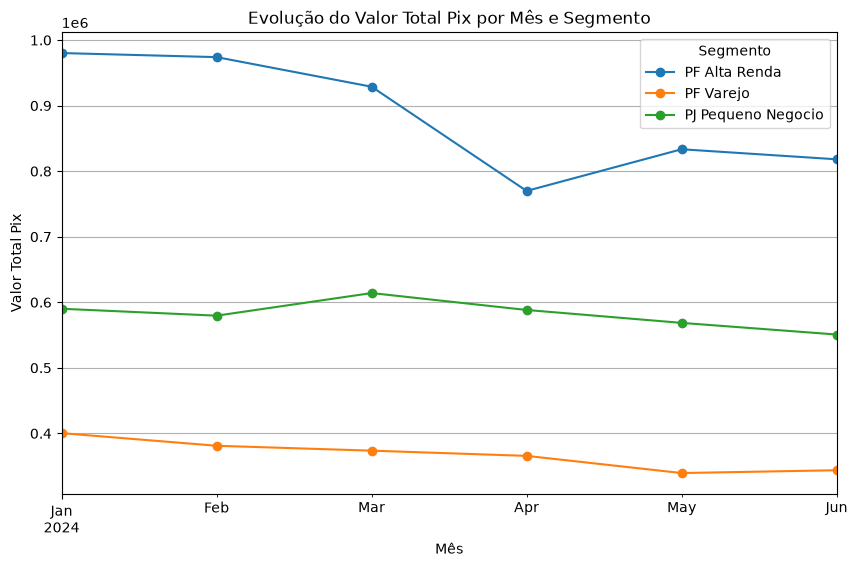

In [38]:
import matplotlib.pyplot as plt

# Criação da tabela pivô com os dados agrupados por mês e segmento
df_pivot = df_pix.pivot_table(
    index='mes', 
    columns='segmento', 
    values='valor_total_pix', 
    aggfunc='sum'
)

# Geração do gráfico de linhas
df_pivot.plot(kind='line', figsize=(10, 6), marker='o')

plt.title('Evolução do Valor Total Pix por Mês e Segmento')
plt.xlabel('Mês')
plt.ylabel('Valor Total Pix')
plt.legend(title='Segmento')
plt.grid(True)
plt.show()